In [12]:
import numpy as np
import torch
import os 
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")

import matplotlib.pyplot as plt

In [6]:
!pwd

/home/hakimmics/projects/AD_MultiPointThreshold


In [10]:
checkpoint = torch.load("results/exp/MVTec_zipper_reconstruction_quantiles_multi_point_2026_06_09_15_49_02/outputs.pt", weights_only=False)
print(checkpoint.keys())

dict_keys(['train_scores', 'test_scores', 'raw_test_labels', 'binary_test_labels', 'prediction'])


In [16]:
scores.shape

(151, 5)

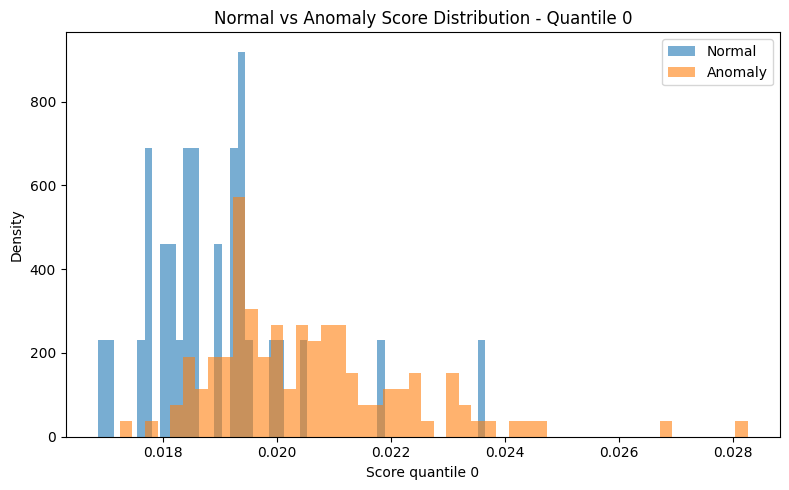

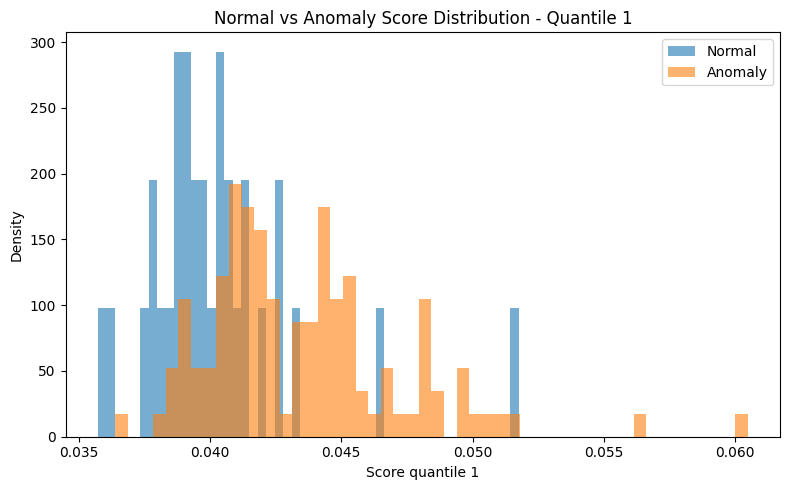

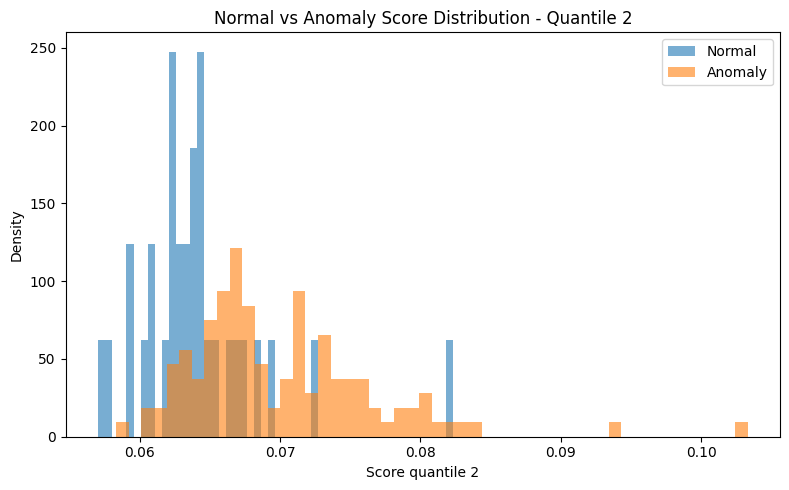

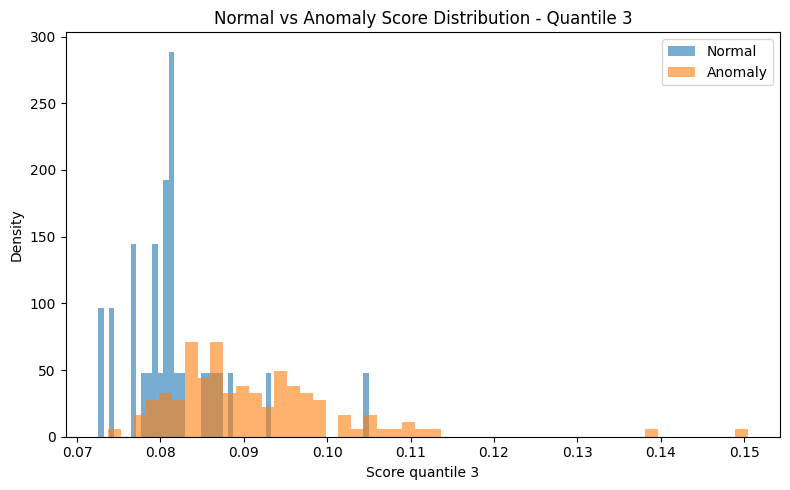

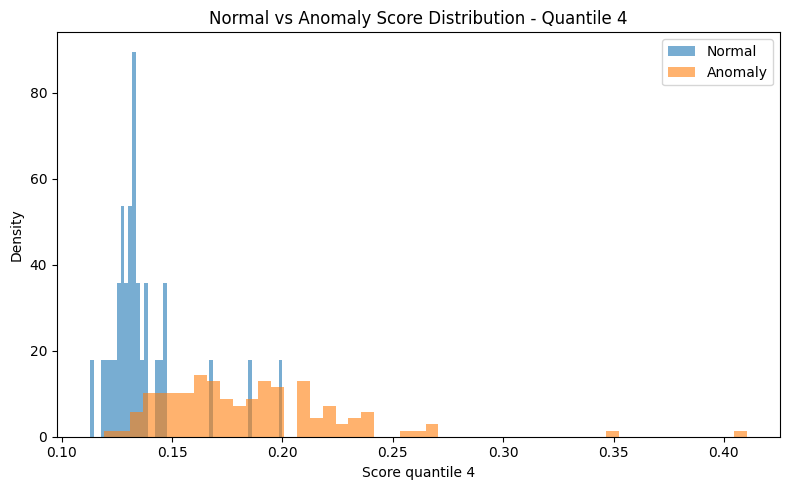

In [17]:
import numpy as np
import matplotlib.pyplot as plt

scores = np.asarray(checkpoint["test_scores"])      # shape: (N, q)
labels = np.asarray(checkpoint["binary_test_labels"])

q = scores.shape[1]

for i in range(q):
    normal_scores = scores[labels == 0, i]
    anomaly_scores = scores[labels == 1, i]

    plt.figure(figsize=(8, 5))
    plt.hist(normal_scores, bins=50, alpha=0.6, density=True, label="Normal")
    plt.hist(anomaly_scores, bins=50, alpha=0.6, density=True, label="Anomaly")
    plt.xlabel(f"Score quantile {i}")
    plt.ylabel("Density")
    plt.title(f"Normal vs Anomaly Score Distribution - Quantile {i}")
    plt.legend()
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_54271/4072039108.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=names, showfliers=False)


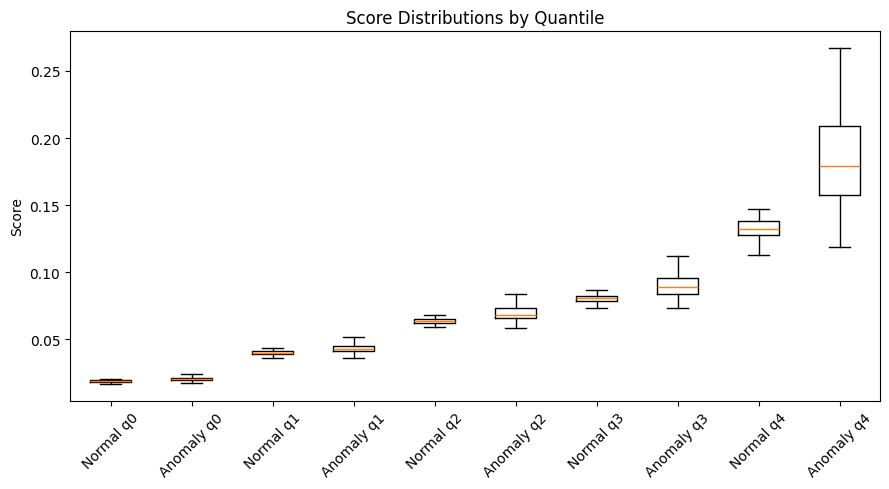

In [18]:
plt.figure(figsize=(9, 5))

data = []
names = []

for i in range(q):
    data.append(scores[labels == 0, i])
    names.append(f"Normal q{i}")
    data.append(scores[labels == 1, i])
    names.append(f"Anomaly q{i}")

plt.boxplot(data, labels=names, showfliers=False)
plt.xticks(rotation=45)
plt.ylabel("Score")
plt.title("Score Distributions by Quantile")
plt.tight_layout()
plt.show()

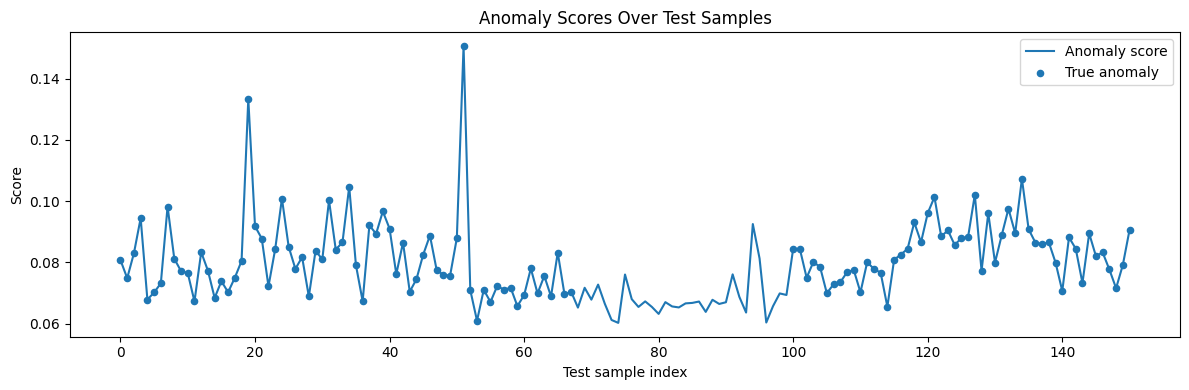

In [20]:
score_agg = scores.mean(axis=1)  # or scores[:, -1] for q=0.99

plt.figure(figsize=(12, 4))
plt.plot(score_agg, label="Anomaly score")
plt.scatter(
    np.where(labels == 1)[0],
    score_agg[labels == 1],
    label="True anomaly",
    s=20
)
plt.xlabel("Test sample index")
plt.ylabel("Score")
plt.title("Anomaly Scores Over Test Samples")
plt.legend()
plt.tight_layout()
plt.show()

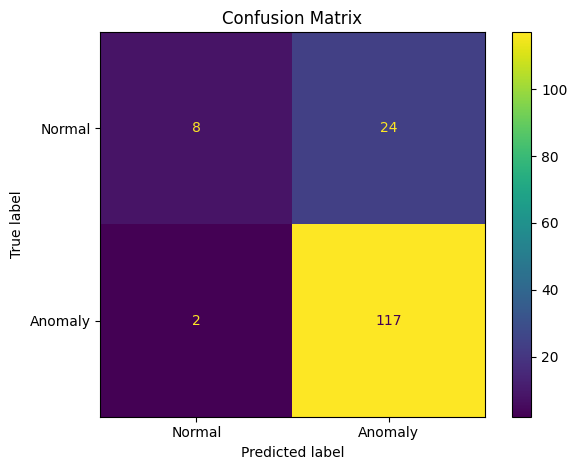

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

pred = np.asarray(checkpoint["prediction"])

cm = confusion_matrix(labels, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)
disp.plot()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

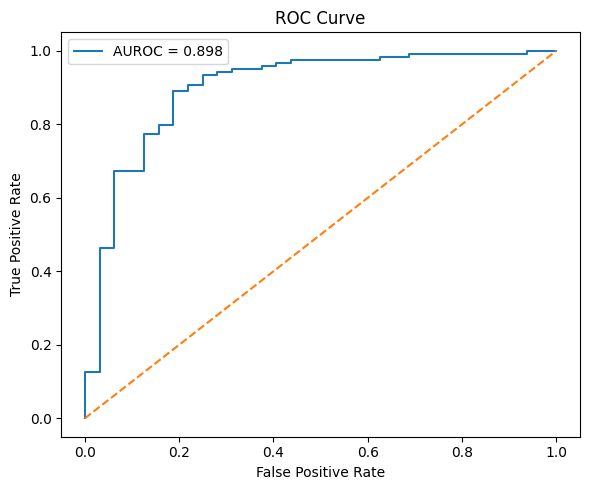

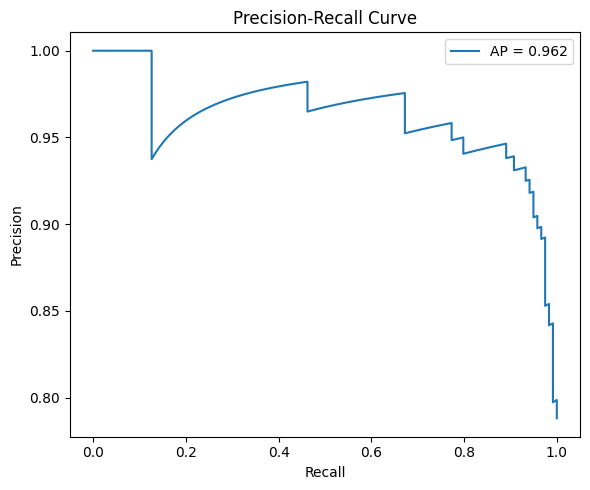

In [22]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

score_agg = scores.mean(axis=1)  # or scores[:, -1]

fpr, tpr, _ = roc_curve(labels, score_agg)
precision, recall, _ = precision_recall_curve(labels, score_agg)

roc_auc = auc(fpr, tpr)
ap = average_precision_score(labels, score_agg)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUROC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

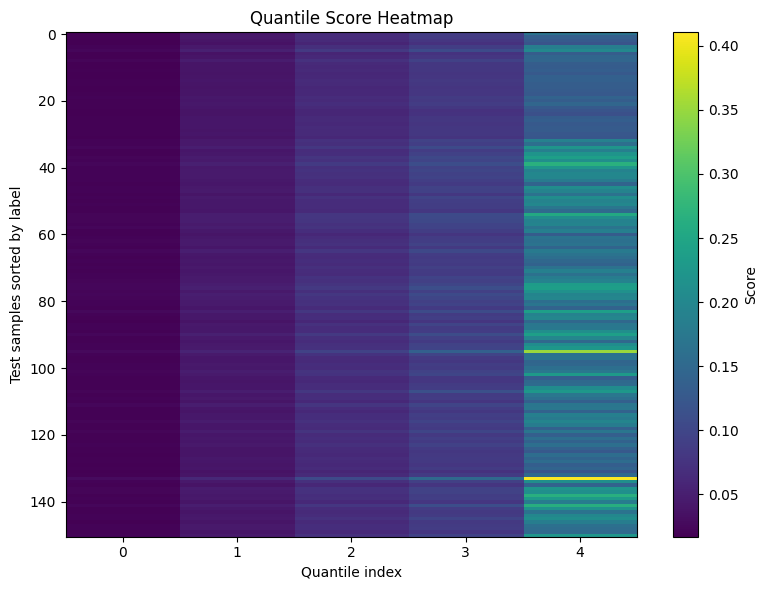

In [23]:
order = np.argsort(labels)

plt.figure(figsize=(8, 6))
plt.imshow(scores[order], aspect="auto")
plt.colorbar(label="Score")
plt.xlabel("Quantile index")
plt.ylabel("Test samples sorted by label")
plt.title("Quantile Score Heatmap")
plt.tight_layout()
plt.show()